# Recherche d'information dans la littérature scientifique

**MOD 7.2 (Introduction à la sciences des données)**, BE séances 4, 5, 6

**Enseignants :** Julien Velcin (CM, BE), Erwan Versmée (BE)

Le projet qu'on vous demande de réaliser est un **moteur de recherche** qui, étant donnée une publication, retourne les articles qui en sont le plus proche sémantiquement.
Pour simplifier le problème, pour une **requête donnée** (*query*), càd un article, on vous fournit 5 articles cités par celui-ci (les exemples positifs) et environ 25 articles choisis aléatoirement dans la base (les exemples négatifs).

La tâche consiste alors à construire un algorithme capable de **retourner les 5 citations et écarter les autres**.

Notez, qu'en plus du titre, d'**autres informations** susceptibles d'être utiles vous sont fournies : court résumé textuel, auteur(s) de l’article, année de publication, références bibliographiques, quels autres articles le citent.

**Exemple :**

Titre de l'article ciblé (notre requête, pour simplifier) : *"Bearish-Bullish Sentiment Analysis on Financial Microblogs"*

Quelques exemples positifs :

> "SemEval-2015 Task 11: Sentiment Analysis of Figurative Language in Twitter"
>
> "Text mining of news-headlines for FOREX market prediction: A Multi-layer Dimension Reduction Algorithm with semantics and sentiment"

Quelques exemples négatifs :

> "Analysis and Design of Average Current Mode Control Using a Describing-Function-Based Equivalent Circuit Model"
>
> "MVOR: A Multi-view RGB-D Operating Room Dataset for 2D and 3D Human Pose Estimation"


Votre moteur se basera sur un système *S* qui doit mesurer à quel point un article candidat *c* répond bien à la requête *q* à l'aide d'un **score d'appariement** S(q,c) : plus ce score est élevé, mieux l'article correspond à la requête.

Si *q* est la requête et *C* l'ensemble des candidats (environ 25 pour chaque requête), composés d'exemples positifs *C+* et négatifs *C-*, alors il faut que *S* retourne préférentiellement les exemples de *C+*, donc leur attribue un score important.


## Setup and Import Libraries

Ici se trouvent un certain nombre de librairies dont vous pourriez avoir besoin. Néanmoins, rien ne vous oblige à tout utiliser et vous pouvez ajouter vos propres librairies. Il est cependant important qu'il soit possible pour une tierce personne d'installer le nécessaire pour exécuter votre code.

In [65]:
import json
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
from typing import Dict, List, Tuple
import os
import pickle
from sklearn.feature_extraction.text import CountVectorizer

import warnings
warnings.filterwarnings('ignore')

# For embeddings and similarity computation
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    print("Required libraries imported successfully!")
except ImportError as e:
    print(f"Missing library: {e}")
    print("Please install with: pip install sentence-transformers scikit-learn networkx")

np.random.seed(42)

Required libraries imported successfully!


Le code qui suit peut être utile pour réaliser des affichages à partir de la matrice Documents x Termes, libre à vous de l'utiliser.

In [66]:
from scipy.sparse import find, csr_matrix
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import norm
from IPython.core.display import HTML

# des options permettent de limiter (ou non) le nombre de lignes/colonnes affichées
# par exemple :
# pd.set_option('display.max_rows', None)

# cette fonction permet d'afficher une "jolie" représentation du vecteur v
# ARGS :
#   v : le vecteur à afficher (par ex. une ligne de la matrice X)
#   features : le vocabulaire
#   top_n : le nombre de mots maximum à afficher
def print_feats(v, features, top_n = 30):
    _, ids, values = find(v)
    feats = [(ids[i], values[i], features[ids[i]]) for i in range(len(list(ids)))]
    top_feats = sorted(feats, key=lambda x: x[1], reverse=True)[0:top_n]
    return pd.DataFrame({"word" : [t[2] for t in top_feats], "value": [t[1] for t in top_feats]})

# fonction qui permet d'afficher plusieurs tables pandas côte à côte (c'est cadeau)
def display_side_by_side(dfs:list, captions:list):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    combined = dict(zip(captions, dfs))
    for caption, df in combined.items():
        output += df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += "&emsp;"
        #output += "\xa0\xa0\xa0"
    display(HTML(output))

## 1. Chargement et prise en main des données

La première étape consiste bien entendu à charger les données en mémoire et aller voir comment celles-ci sont structurées. On vous fournit 3 fichiers pour commencer :

- *corpus.jsonl* : le corpus lui-même, composé de plus de 25k articles scientifiques
- *queries.jsonl* : l'ensemble des documents qui constituent les requêtes qui seront adressées à notre moteur. Ces documents proviennent du corpus, mais il peut s'agir de documents qui ne sont que cités ou citent d'autres documents et pour lesquels on n'a que très peu d'information.
- *valid.tsv* : l'ensemble des données nécessaires pour entraîner et/ou tester votre moteur

Voilà un extrait du fichier *corpus.jsonl* :

![corpus](./corpus.jpg "Title")

Voilà un extrait du fichier *queries.jsonl* :

![corpus](./queries.jpg "Title")

Voilà un extrait du fichier *valid.tsv* :

![corpus](./test.jpg "Title")

Par la suite, on vous fournira à priori un 4ème fichier (*test_final.tsv*) qui contiendra des nouvelles données sur lesquelles vous pourrez réaliser  des prédictions. Les identifiants des candidats sont toujours tirés de votre corpus d'articles.

Nous vous conseillons d'employer la libraire *json* pour charger les données des deux premiers fichiers et utiliser des dictionnaires afin de pouvoir accéder aux articles via leurs identifiants. Pour rappel, un fichier *jsonl* n'est rien d'autre qu'un fichier dans lequel chaque ligne est composé d'un objet json bien formaté.

In [67]:
import pandas as pd
import json

def load_corpus(file_path: str) -> Dict[str, Dict]:
    """
    Charge le corpus depuis un fichier JSONL.
    Retourne un dictionnaire {doc_id: document_data}.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        df = pd.DataFrame(json.loads(line) for line in f)

    # Normalisation : renomme la colonne _id -> id si nécessaire
    if "_id" in df.columns:
        df = df.rename(columns={"_id": "id"})

    # Conversion en dictionnaire indexé par 'id'
    return {row["id"]: row.to_dict() for _, row in df.iterrows()}

def load_queries(file_path: str) -> Dict[str, Dict]:
    """
    Charge les requêtes depuis un fichier JSONL.
    Retourne un dictionnaire {query_id: query_data}.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        df = pd.DataFrame(json.loads(line) for line in f)

    if "_id" in df.columns:
        df = df.rename(columns={"_id": "id"})

    return {row["id"]: row.to_dict() for _, row in df.iterrows()}

def load_qrels(file_path: str) -> Dict[str, Dict[str, int]]:
    """
    Charge les jugements de pertinence depuis un TSV.
    Retourne {query_id: {doc_id: score}}.
    """
    # Chargement du TSV
    valid = pd.read_csv(file_path, sep="\t")
    valid = valid.rename(columns={
        "query-id": "query_id",
        "corpus-id": "doc_id",
        "score": "relevance"
    })

    qrels_dict = {}
    for _, row in valid.iterrows():
        qid = str(row["query_id"])
        docid = str(row["doc_id"])
        rel = int(row["relevance"])
        qrels_dict.setdefault(qid, {})[docid] = rel

    return qrels_dict

In [30]:
# Load the dataset
print("Loading dataset...")
corpus = load_corpus('corpus.jsonl')
queries = load_queries('queries.jsonl')
qrels_valid = load_qrels('valid.tsv')


print(f"Loaded {len(corpus)} documents in corpus")
print(f"Loaded {len(queries)} queries")
print(f"Loaded relevance for {len(qrels_valid)} queries (dataset)")

Loading dataset...
Loaded 25657 documents in corpus
Loaded 1000 queries
Loaded relevance for 700 queries (dataset)


## 2. Exploration des données et premier encodage

A présent, on vous propose de réaliser un certain nombre d'opérations pour mieux connaître vos données. Tout d'abord, il s'agit de calculer des statistiques simples telles que :

- Taille du corpus et du nombre de requêtes
- Nombre de paires requête / document
- Proportions de documents pertinents (non pertinents) par requête

Affichez ensuite un exemple de requête (vous pouvez vous limiter au titre de l'article), accompagnée d'exemples de candidats positifs et de candidats négatifs.

In [68]:
# Calcul des statistiques basiques
print(f"Nombre de documents dans le corpus : {len(corpus)}")
print(f"Nombre de requêtes : {len(queries)}")
print(f"Nombre de requêtes avec jugements (qrels) : {len(qrels_valid)}")

total_pairs = sum(len(docs) for docs in qrels_valid.values())
print(f"Nombre total de paires requête / document : {total_pairs}")

# Statistiques détaillées par requête (pertinents vs non-pertinents)
stats = {}
for qid, doc_scores in qrels_valid.items():
    total = len(doc_scores)
    n_relevant = sum(1 for score in doc_scores.values() if score > 0)
    n_non_relevant = total - n_relevant

    stats[qid] = {
        "total_docs": total,
        "relevant": n_relevant,
        "non_relevant": n_non_relevant,
        "prop_relevant": n_relevant / total if total > 0 else 0.0
    }

print("\nExemple de statistiques pour 5 requêtes :")
print(json.dumps(dict(list(stats.items())[:5]), indent=2))

Nombre de documents dans le corpus : 25657
Nombre de requêtes : 1000
Nombre de requêtes avec jugements (qrels) : 700
Nombre total de paires requête / document : 20950

Exemple de statistiques pour 5 requêtes :
{
  "40c6b953b5c04b3df4164cd487c4bc00cf0e487d": {
    "total_docs": 29,
    "relevant": 4,
    "non_relevant": 25,
    "prop_relevant": 0.13793103448275862
  },
  "2dbe49d7c9a65656cd46d22ea07dc317b26482b6": {
    "total_docs": 30,
    "relevant": 5,
    "non_relevant": 25,
    "prop_relevant": 0.16666666666666666
  },
  "54356ff0960100e27cf17ff682825bba2662e90c": {
    "total_docs": 30,
    "relevant": 5,
    "non_relevant": 25,
    "prop_relevant": 0.16666666666666666
  },
  "f1256b20d202c73022d7a7f0151ba0010a074a06": {
    "total_docs": 30,
    "relevant": 5,
    "non_relevant": 25,
    "prop_relevant": 0.16666666666666666
  },
  "8cb5835c4b4e042238304bfe7b0d96456714638a": {
    "total_docs": 30,
    "relevant": 5,
    "non_relevant": 25,
    "prop_relevant": 0.1666666666666666

Ensuite, utilisez la librairie *scikit-learn* pour réaliser un **premier encodage des données** sous forme de matrice Documents * Termes.
Il suffit pour cela d'utiliser la classe *CountVectorizer* puis d'utiliser les fonction *fit* et *transform* pour (respectivement) construire le vocabulaire et la matrice elle-même.
Pour simplifier et accélérer les calculs, vous pouvez commencer en ne considérant que le titre des articles, mais rien ne vous empêche par la suite d'utiliser également le champ résumé.

Pour le moment, contentez-vous d'utiliser les paramètres par défaut, mais vous pourrez ensuite appliquer de **nombreux prétraitements** tels que la suppression des mots-outils ou la réduction de la taille du vocabulaire. Nous verrons ça dans la section suivante.

En utilisant la fonction fournie *print_feats*, affichez les informations contenues dans quelques vecteurs de la base de données.

In [69]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Préparation des données : extraction des titres
# On crée une liste ordonnée pour s'assurer que l'index de la matrice correspond bien à nos IDs
doc_ids = list(corpus.keys())
titles = [corpus[doc_id].get("title", "") for doc_id in doc_ids]

# 2. Vectorisation (Bag of Words simple)
# Suppression des stop words anglais pour nettoyer un peu
vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(titles)

print("Dimensions de la matrice Documents x Termes :", X.shape)
vocab = vectorizer.get_feature_names_out()

def print_feats_custom(vector, vocab, topn=10):
    """Affiche les termes les plus fréquents d'un vecteur"""
    indices = vector.nonzero()[1]
    counts = vector.toarray().flatten()
    feats = [(vocab[i], counts[i]) for i in indices]
    feats = sorted(feats, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(feats[:topn], columns=["Terme", "Fréquence"])

print("\nContenu du vecteur pour le premier document :")
display(print_feats_custom(X[0], vocab))

Dimensions de la matrice Documents x Termes : (25657, 19840)

Contenu du vecteur pour le premier document :


,Terme,Fréquence
0,hybrid,1
1,genetic,1
2,algorithm,1
3,particle,1
4,swarm,1
5,optimization,1
6,recurrent,1
7,network,1
8,design,1


Affichez la distribution des mots les plus fréquemment employés dans le corpus. Pour cela, il suffit de faire la somme des occurrences par colonne, puis d'appeler la fonction d'affichage précédente. Ensuite, vous pouvez utiliser la librairie *matplotlib* pour afficher un histogramme qui permet d'avoir une représentation visuelle de cette distribution.

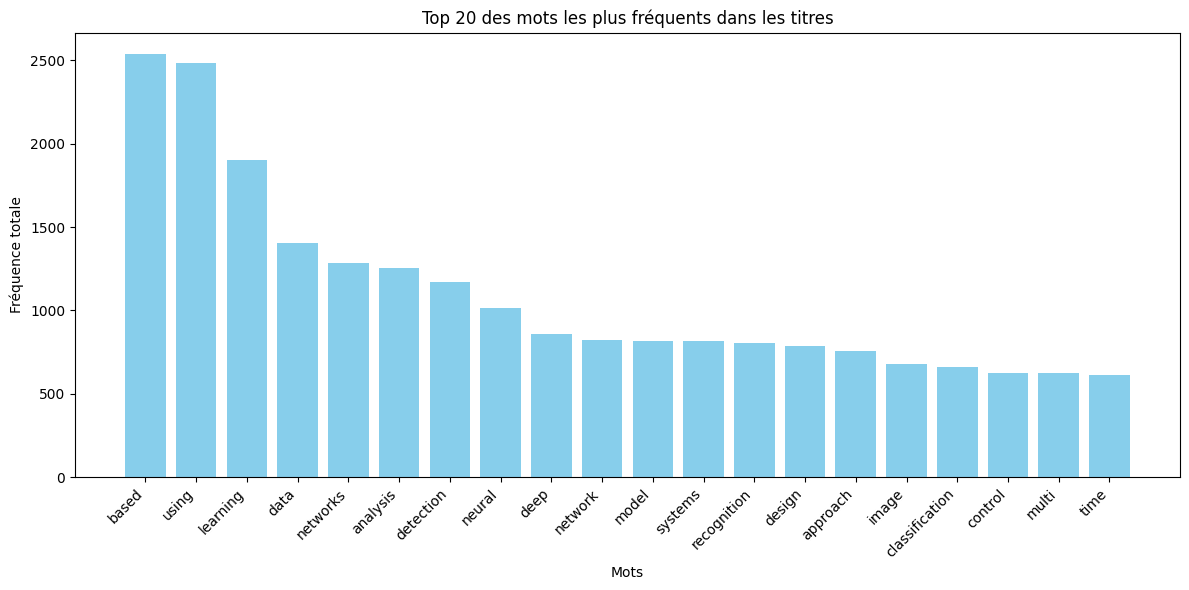

In [70]:
# Somme des occurrences par colonne (mot) sur tout le corpus
word_counts = np.asarray(X.sum(axis=0)).flatten()

# Tri des indices par fréquence décroissante
sorted_indices = np.argsort(word_counts)[::-1]
topn = 20

top_words = vocab[sorted_indices][:topn]
top_counts = word_counts[sorted_indices][:topn]

# Affichage Graphique
plt.figure(figsize=(12, 6))
plt.bar(top_words, top_counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title(f"Top {topn} des mots les plus fréquents dans les titres")
plt.xlabel("Mots")
plt.ylabel("Fréquence totale")
plt.tight_layout()
plt.show()

## 3. Comparaison de documents et premier moteur de recherche

Une manière classique de comparer des vecteurs creux (ce qui est le cas pour la matrice Documents x Termes) est d'utiliser la mesure du cosinus. Celle-ci calcule une **similarité entre deux textes** basée sur les mots en commun.

En utilisant la fonction *cosine_similarity* de la *librairie sklearn*, testez cette mesure sur différentes paires de texte. Vous pouvez également travailler avec les résumés des articles. N'hésitez pas à afficher les documents pour observer les mots qu'ils ont en commun.

In [71]:
from sklearn.metrics.pairwise import cosine_similarity

# Exemple de similarité entre deux documents arbitraires (ex: 0 et 1)
doc_idx_1 = 0
doc_idx_2 = 1

sim = cosine_similarity(X[doc_idx_1], X[doc_idx_2])[0, 0]

print(f"Titre Doc 1 : {titles[doc_idx_1]}")
print(f"Titre Doc 2 : {titles[doc_idx_2]}")
print(f"Similarité Cosinus : {sim:.4f}")

# Recherche des mots communs
vec1 = X[doc_idx_1].toarray().flatten()
vec2 = X[doc_idx_2].toarray().flatten()
common_indices = (vec1 > 0) & (vec2 > 0)
common_words = [vocab[i] for i in range(len(vocab)) if common_indices[i]]
print(f"Mots en commun : {common_words}")

Titre Doc 1 : A hybrid of genetic algorithm and particle swarm optimization for recurrent network design
Titre Doc 2 : A Hybrid EP and SQP for Dynamic Economic Dispatch with Nonsmooth Fuel Cost Function
Similarité Cosinus : 0.1054
Mots en commun : ['hybrid']


Vous pouvez à présent écrire un **petit moteur de recherche** qui prend un ensemble de mots clefs, calcule un score pour chaque document de la base et retourne les 10 premieres résultats.

Pour cela, les différentes étapes sont les suivantes :

1. Construire le vecteur requête à partir du texte
1. Calculer le score (cosinus) entre la requête et tous les documents du corpus
1. Triez les résultats et affichez les 10 premiers articles

Pour la première étape, vous pouvez utiliser directement le "vectoriseur" pour construire le vecteur requête dans le même espace de vocabulaire que le corpus (fonction *transform*).

In [72]:
def search_engine(query: str, vectorizer, Matrix_X, corpus_ids: list, corpus_data: dict, topk=10):
    """
    Moteur de recherche simple :
    1. Vectorise la requête
    2. Calcule la similarité avec tout le corpus
    3. Retourne les top-k résultats
    """
    # 1. Vectorisation requête
    q_vec = vectorizer.transform([query])

    # 2. Calcul similarité (produit scalaire normalisé)
    # cosine_similarity retourne une matrice (1, n_docs), on prend la ligne 0
    sims = cosine_similarity(q_vec, Matrix_X)[0]

    # 3. Tri des résultats (argsort trie par ordre croissant, donc on inverse avec [::-1])
    top_indices = np.argsort(sims)[::-1][:topk]

    results = []
    for rank, idx in enumerate(top_indices):
        doc_id = corpus_ids[idx]
        score = sims[idx]
        # On ne garde que les résultats avec un score > 0 pour éviter le bruit
        if score > 0:
            results.append({
                "rank": rank + 1,
                "doc_id": doc_id,
                "score": score,
                "title": corpus_data[doc_id].get("title", "No Title")
            })

    return results

# Test du moteur
query_test = "genetic algorithm optimization"
results = search_engine(query_test, vectorizer, X, doc_ids, corpus, topk=5)

print(f"Résultats pour la requête : '{query_test}'\n")
for r in results:
    print(f"Rank {r['rank']} | Score: {r['score']:.4f} | {r['title']}")

Résultats pour la requête : 'genetic algorithm optimization'

Rank 1 | Score: 0.7071 | MOS PARAMETER EXTRACTION AND OPTIMIZATION WITH GENETIC ALGORITHM
Rank 2 | Score: 0.6667 | The Whale Optimization Algorithm
Rank 3 | Score: 0.6667 | Bayesian Optimization Algorithm
Rank 4 | Score: 0.6547 | A GENETIC ALGORITHM FOR STRUCTURAL OPTIMIZATION OF STEEL TRUSS ROOFS
Rank 5 | Score: 0.6124 | Spider Monkey Optimization algorithm for numerical optimization


Pour en finir avec cette approche classique "creuse", vous pouvez essayer des variantes :

- Modifier les paramètres du "vectoriseur" : taille du vocabulaire, suppression des mots-outils, suppression des mots trop rares ou trop fréquents, stemming
- Utiliser une autre pondération, comme **TFxIDF**

In [73]:
from itertools import islice
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from nltk.stem.snowball import FrenchStemmer

### APPROCHE CREUSE COMPLÈTE (Chargement, BoW, Analyses, Variantes TF-IDF)

In [76]:
# 1) LOAD CORPUS.JSONL
with open("corpus.jsonl", "r", encoding="utf-8") as f:
    corpus_tf = pd.DataFrame(json.loads(line) for line in f)

# Normalisation : renomme la colonne _id -> id
if "_id" in corpus_tf.columns:
    corpus_tf = corpus_tf.rename(columns={"_id": "id"})

# 2) LOAD QUERIES.JSONL
with open("queries.jsonl", "r", encoding="utf-8") as f:
    queries_tf = pd.DataFrame(json.loads(line) for line in f)

if "_id" in queries_tf.columns:
    queries_tf = queries_tf.rename(columns={"_id": "id"})

# 3) LOAD VALID.TSV
valid_tf = pd.read_csv("valid.tsv", sep="\t")
valid_tf = valid_tf.rename(columns={
    "query-id": "query_id",
    "corpus-id": "doc_id",
    "score": "relevance"
})

# 4) BUILD DICTIONARIES
corpus_dict_tf = {row["id"]: row.to_dict() for _, row in corpus_tf.iterrows()}
queries_dict_tf = {row["id"]: row.to_dict() for _, row in queries_tf.iterrows()}
qrels_dict_tf = {}
for _, row in valid_tf.iterrows():
    qid = str(row["query_id"])
    docid = str(row["doc_id"])
    rel = int(row["relevance"])
    qrels_dict_tf.setdefault(qid, {})[docid] = rel

print("Nombre de documents dans le corpus :", len(corpus_dict_tf))
print("Nombre de requêtes :", len(queries_dict_tf))
print("Nombre de requêtes avec jugements de pertinence :", len(qrels_dict_tf))

total_pairs = sum(len(docs) for docs in qrels_dict_tf.values())
print("Nombre total de paires requête / document :", total_pairs)

# Statistiques simples sur les qrels
stats = {}
for qid, doc_scores in qrels_dict_tf.items():
    total = len(doc_scores)
    n_relevant = sum(1 for score in doc_scores.values() if score > 0)
    n_non_relevant = total - n_relevant
    stats[qid] = {
        "total_docs": total,
        "relevant": n_relevant,
        "non_relevant": n_non_relevant,
        "prop_relevant": n_relevant / total if total > 0 else 0.0,
        "prop_non_relevant": n_non_relevant / total if total > 0 else 0.0
    }

print("\nExemple de stats (5 premières requêtes) :")
print(json.dumps(dict(islice(stats.items(), 5)), indent=2))


Nombre de documents dans le corpus : 25657
Nombre de requêtes : 1000
Nombre de requêtes avec jugements de pertinence : 700
Nombre total de paires requête / document : 20950

Exemple de stats (5 premières requêtes) :
{
  "40c6b953b5c04b3df4164cd487c4bc00cf0e487d": {
    "total_docs": 29,
    "relevant": 4,
    "non_relevant": 25,
    "prop_relevant": 0.13793103448275862,
    "prop_non_relevant": 0.8620689655172413
  },
  "2dbe49d7c9a65656cd46d22ea07dc317b26482b6": {
    "total_docs": 30,
    "relevant": 5,
    "non_relevant": 25,
    "prop_relevant": 0.16666666666666666,
    "prop_non_relevant": 0.8333333333333334
  },
  "54356ff0960100e27cf17ff682825bba2662e90c": {
    "total_docs": 30,
    "relevant": 5,
    "non_relevant": 25,
    "prop_relevant": 0.16666666666666666,
    "prop_non_relevant": 0.8333333333333334
  },
  "f1256b20d202c73022d7a7f0151ba0010a074a06": {
    "total_docs": 30,
    "relevant": 5,
    "non_relevant": 25,
    "prop_relevant": 0.16666666666666666,
    "prop_non_r

In [78]:
def search(query, vectorizer, X, corpus_df, topk=10):
    """
    Moteur de recherche simple basé sur :
    - CountVectorizer
    - similarité cosinus
    """
    # 1. Vectorisation requête
    q_vec = vectorizer.transform([query])
    # 2. Similarité
    sims = cosine_similarity(q_vec, X)[0]
    # 3. Tri
    top_indices = sims.argsort()[::-1][:topk]

    results = []
    for idx in top_indices:
        results.append({
            "rank": len(results) + 1,
            "doc_id": idx,
            "score": sims[idx],
            "title": corpus_df.iloc[idx]["title"]
        })
    return results

test_query_tf = "genetic algorithm optimization"
print(f"Test de recherche pour : '{test_query_tf}'")
results = search(test_query_tf, vectorizer, X, corpus_tf, topk=10)

for r in results:
    print(f"Rank {r['rank']} | Score={r['score']:.4f} | {r['title']}")



Test de recherche pour : 'genetic algorithm optimization'
Rank 1 | Score=0.7071 | MOS PARAMETER EXTRACTION AND OPTIMIZATION WITH GENETIC ALGORITHM
Rank 2 | Score=0.6667 | The Whale Optimization Algorithm
Rank 3 | Score=0.6667 | Bayesian Optimization Algorithm
Rank 4 | Score=0.6547 | A GENETIC ALGORITHM FOR STRUCTURAL OPTIMIZATION OF STEEL TRUSS ROOFS
Rank 5 | Score=0.6124 | Spider Monkey Optimization algorithm for numerical optimization
Rank 6 | Score=0.5774 | BOA: the Bayesian optimization algorithm
Rank 7 | Score=0.5774 | A hybrid of genetic algorithm and particle swarm optimization for recurrent network design
Rank 8 | Score=0.5774 | Optimization of the internal grid of an offshore wind farm using Genetic algorithm
Rank 9 | Score=0.5477 | GENETIC ALGORITHM APPLIED TO OPTIMIZATION OF THE SHIP HULL FORM WITH RESPECT TO SEAKEEPING PERFORMANCE
Rank 10 | Score=0.5477 | Improved Algorithm for Intrusion Detection Using Genetic Algorithm and SNORT


###PRÉTRAITEMENTS AVANCÉS ET TF-IDF (Stopwords, Stemming, TF-IDF)

In [80]:
# A. CountVectorizer avec stopwords EN
vectorizer_stop_tf = CountVectorizer(stop_words="english")
X_stop_tf = vectorizer_stop_tf.fit_transform(titles)
print("Taille vocab (stopwords supprimés) :", len(vectorizer_stop_tf.get_feature_names_out()))

# B. min_df / max_df
vectorizer_df_tf = CountVectorizer(min_df=3, max_df=0.8)
X_df = vectorizer_df_tf.fit_transform(titles)
print("Taille vocab (min_df=3, max_df=0.8) :", len(vectorizer_df_tf.get_feature_names_out()))

# C. Stemming
stemmer = FrenchStemmer()

def stem_tokenizer(text):
    tokens_tf = text.lower().split()
    return [stemmer.stem(t) for t in tokens_tf]

print("Construction de la matrice avec Stemming...")
vectorizer_stem_tf = CountVectorizer(tokenizer=stem_tokenizer, token_pattern=None, lowercase=False)
X_stem_tf = vectorizer_stem_tf.fit_transform(titles)
print("Taille vocab après stemming :", len(vectorizer_stem_tf.get_feature_names_out()))

# D. TF-IDF sur les titres
print("Construction de la matrice TF-IDF...")
tfidf_vectorizer_tf = TfidfVectorizer(stop_words="english")
X_tfidf_tf = tfidf_vectorizer_tf.fit_transform(titles)
print("Dimensions TF-IDF :", X_tfidf_tf.shape)

# Test du moteur avec la version TF-IDF
print(f"\nRésultats TF-IDF pour : '{test_query_tf}'")
results_tfidf = search(test_query_tf, tfidf_vectorizer_tf, X_tfidf_tf, corpus_tf, topk=10)

for r in results_tfidf:
    print(f"Rank {r['rank']} | Score={r['score']:.4f} | {r['title']}")

Taille vocab (stopwords supprimés) : 19840
Taille vocab (min_df=3, max_df=0.8) : 7205
Construction de la matrice avec Stemming...
Taille vocab après stemming : 28270
Construction de la matrice TF-IDF...
Dimensions TF-IDF : (25657, 19840)

Résultats TF-IDF pour : 'genetic algorithm optimization'
Rank 1 | Score=0.6080 | MOS PARAMETER EXTRACTION AND OPTIMIZATION WITH GENETIC ALGORITHM
Rank 2 | Score=0.5656 | Genetic Algorithms in Search Optimization and Machine Learning
Rank 3 | Score=0.5641 | Bayesian Optimization Algorithm
Rank 4 | Score=0.5607 | A hybrid of genetic algorithm and particle swarm optimization for recurrent network design
Rank 5 | Score=0.5489 | Optimization of Control Parameters for Genetic Algorithms
Rank 6 | Score=0.5236 | An Implementation of Intrusion Detection System Using Genetic Algorithm
Rank 7 | Score=0.5097 | Improved Algorithm for Intrusion Detection Using Genetic Algorithm and SNORT
Rank 8 | Score=0.4756 | A GENETIC ALGORITHM FOR STRUCTURAL OPTIMIZATION OF STE

## 4. Utiliser un meilleur encodeur de documents

L'encodage dans un espace de mots avec TF ou TFxIDF a de nombreuses limites. On utilise aujourd'hui des encodeurs spécialisés pour construire des **représentations denses** beaucoup plus adaptées (cf. cours).

La librairie [sentence-transformers](https://www.sbert.net) propose de très nombreux modèles près à l'emploi. Vous pouvez en choisir un par défaut (comme all-MiniLM-L6-v2, qui est assez rapide et permet d'obtenir des bonnes performances) ou vous laisser guider par les tests réalisés sur le benchmark [MTEB](https://huggingface.co/spaces/mteb/leaderboard).

Attention, suivant la puissance de votre machine (et la présence ou non d'un GPU), l'encodage peut prendre un certain temps. Nous vous conseillons de ne faire le calcul qu'**une seule fois** sur l'ensemble de votre corpus et de stocker les représentations (embeddings) ainsi construit dans un fichier.

Une alternative consiste à construire un index efficace via un **vector store** tel que [FAISS](https://faiss.ai/index.html).

###- Rechargement et Structuration des Données

In [82]:
import pandas as pd
import json

# Rechargement et Structuration des Données

# A. Chargement des Requêtes (Queries)
# On convertit immédiatement en Dictionnaire pour accès rapide : queries_dict["id"]
with open("queries.jsonl", "r", encoding="utf-8") as f:
    queries_df = pd.DataFrame(json.loads(line) for line in f)
# Normalisation id
if "_id" in queries_df.columns:
    queries_df = queries_df.rename(columns={"_id": "id"})
# Création du dictionnaire {id: {data}}
queries_dict = queries_df.set_index("id").to_dict("index")

# B. Chargement du Corpus
# Idem, on veut un accès rapide par ID
with open("corpus.jsonl", "r", encoding="utf-8") as f:
    corpus_df = pd.DataFrame(json.loads(line) for line in f)
if "_id" in corpus_df.columns:
    corpus_df = corpus_df.rename(columns={"_id": "id"})
corpus_dict = corpus_df.set_index("id").to_dict("index")

# C. Chargement de la Vérité Terrain (Valid.tsv)
valid_df = pd.read_csv("valid.tsv", sep="\t")
valid_df = valid_df.rename(columns={"query-id": "query_id", "corpus-id": "doc_id", "score": "relevance"})

# Dictionnaire qrels: {query_id: {doc_id: relevance}}
qrels_valid = {}
for _, row in valid_df.iterrows():
    qid = str(row["query_id"])
    did = str(row["doc_id"])
    rel = int(row["relevance"])
    qrels_valid.setdefault(qid, {})[did] = rel

print(f"Données prêtes : {len(queries_dict)} requêtes, {len(corpus_dict)} documents.")

Données prêtes : 1000 requêtes, 25657 documents.


###- Encodage avec all-MiniLM-L6-v2

In [83]:
import os
import pickle
import numpy as np
from sentence_transformers import SentenceTransformer
import torch

# Configuration
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
EMBEDDING_FILE = 'corpus_embeddings_mini.pkl'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"--- 2. Chargement du modèle {MODEL_NAME} sur {device.upper()} ---")
model = SentenceTransformer(MODEL_NAME, device=device)

# Liste ordonnée des IDs (essentiel pour mapper index <-> doc_id)
doc_ids_list = list(corpus_dict.keys())

# Vérification si le fichier existe déjà
if os.path.exists(EMBEDDING_FILE):
    print(f"Chargement des embeddings depuis {EMBEDDING_FILE}...")
    with open(EMBEDDING_FILE, "rb") as fIn:
        stored_data = pickle.load(fIn)
        corpus_embeddings = stored_data['embeddings']
        saved_ids = stored_data['doc_ids']

        if len(saved_ids) != len(doc_ids_list):
            doc_ids_list = saved_ids
else:
    print("Calcul des embeddings en cours (ceci peut prendre quelques minutes)...")

    # On concatène Titre + Texte pour une meilleure représentation
    corpus_texts = []
    for did in doc_ids_list:
        d = corpus_dict[did]
        full_text = (d.get("title", "") + " " + d.get("text", "")).strip()
        corpus_texts.append(full_text)

    # Encodage
    corpus_embeddings = model.encode(corpus_texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)

    # Sauvegarde
    print(f"Sauvegarde dans {EMBEDDING_FILE}...")
    with open(EMBEDDING_FILE, "wb") as fOut:
        pickle.dump({'doc_ids': doc_ids_list, 'embeddings': corpus_embeddings}, fOut)

# Création du mapping inverse pour la recherche : ID -> Index
id_to_index = {did: i for i, did in enumerate(doc_ids_list)}
print(f"Embeddings prêts. Dimensions : {corpus_embeddings.shape}")

--- 2. Chargement du modèle sentence-transformers/all-MiniLM-L6-v2 sur CUDA ---
Chargement des embeddings depuis corpus_embeddings_mini.pkl...
Embeddings prêts. Dimensions : (25657, 384)


Cette partie permet de charger les embeddings en mémoire s'ils ont déjà été stockés dans un fichier.

In [84]:
EMBEDDING_FILE = "corpus_embeddings.pkl"

if os.path.exists(EMBEDDING_FILE):
    print(f"Chargement des embeddings depuis {EMBEDDING_FILE}...")
    with open(EMBEDDING_FILE, "rb") as fIn:
        stored_data = pickle.load(fIn)

    # On récupère la matrice et la liste d'IDs
    corpus_embeddings_matrix = stored_data['embeddings']
    corpus_ids_list = stored_data['doc_ids']

    # Création d'un dictionnaire {doc_id: index_dans_la_matrice} pour un accès ultra-rapide
    id_to_index = {doc_id: idx for idx, doc_id in enumerate(corpus_ids_list)}

    print(f"Succès ! {len(corpus_embeddings_matrix)} documents chargés.")
    print(f"Dimension des vecteurs : {corpus_embeddings_matrix.shape}")
else:
    print("ERREUR : Veuillez générer le fichier.")

Chargement des embeddings depuis corpus_embeddings.pkl...
Succès ! 25657 documents chargés.
Dimension des vecteurs : (25657, 384)


## 5. Nouveau moteur de recherche

A présent, l'objectif est double :

1. Implémenter un **moteur de recherche**, mais cette fois en vous basant sur les représentations denses construites à l'étape précédente.
2. **Evaluer** la pertinence de votre moteur grâce aux annotations fournies dans le fichier *valid.tsv* qui portent sur les requêtes de *query.tsv* : pour une requête donnée, votre système doit retourner préférentiellement les articles pertinents (score noté 1) en comparaison des articles non pertinents (score noté 0).

Commencez par implémenter le moteur de recherche proprement dit : à partir d'une requête, le système doit trier les 25 documents candidats fournis.

In [85]:
from sklearn.metrics.pairwise import cosine_similarity

def dense_search(query_text, candidate_ids, model, embeddings, id_map, topk=5):
    """Effectue une recherche sémantique parmi une liste de candidats."""
    # 1. Encoder la requête
    q_emb = model.encode([query_text], convert_to_numpy=True)[0]

    # 2. Récupérer les vecteurs des candidats valides
    valid_indices = []
    valid_candidates = []

    for cid in candidate_ids:
        if cid in id_map:
            valid_indices.append(id_map[cid])
            valid_candidates.append(cid)

    if not valid_indices:
        return []

    # 3. Calculer la similarité cosinus
    candidate_matrix = embeddings[valid_indices]
    # Reshape (1, -1) pour q_emb est géré par cosine_similarity, mais array([q_emb]) est plus sûr
    sims = cosine_similarity([q_emb], candidate_matrix)[0]

    # 4. Trier les résultats
    # argsort trie croissant, on inverse avec [::-1]
    sorted_args = np.argsort(sims)[::-1][:topk]

    results = []
    for idx in sorted_args:
        doc_id = valid_candidates[idx]
        results.append({
            "doc_id": doc_id,
            "score": sims[idx],
            "title": corpus_dict[doc_id].get("title", "Sans titre")
        })
    return results

Prenez quelques requêtes en exemple et affichez le résultat de votre moteur. On doit pouvoir vérifier si les 5 premiers résultats sont bien pertinents (score de 1).

In [86]:
# On prend une requête qui existe dans la validation
sample_qid = list(qrels_valid.keys())[0]

q_data = queries_dict[sample_qid]
query_text = q_data.get("title", "") or q_data.get("text", "")

candidates = list(qrels_valid[sample_qid].keys())

print(f"Requête ID : {sample_qid}")
print(f"Texte      : {query_text}")
print(f"Nb candidats : {len(candidates)}")

results = dense_search(query_text, candidates, model, corpus_embeddings, id_to_index)

print("\nRésultats Top 5 :")
for i, r in enumerate(results):
    # Vérification si pertinent (score=1)
    is_rel = qrels_valid[sample_qid].get(r["doc_id"], 0)
    status = "[PERTINENT]" if is_rel > 0 else "[Non Pertinent]"
    print(f"{i+1}. Score={r['score']:.4f} {status} -> {r['title'][:60]}...")


Requête ID : 40c6b953b5c04b3df4164cd487c4bc00cf0e487d
Texte      : A Microfluidically Reconfigurable Dual-Band Slot Antenna With a Frequency Coverage Ratio of 3:1
Nb candidats : 29

Résultats Top 5 :
1. Score=0.5915 [PERTINENT] -> A Coplanar Reconfigurable Folded Slot Antenna Without Bias N...
2. Score=0.3804 [PERTINENT] -> Continuous Electrowetting of Non-toxic Liquid Metal for RF A...
3. Score=0.3350 [PERTINENT] -> A Low-Profile Third-Order Bandpass Frequency Selective Surfa...
4. Score=0.1037 [Non Pertinent] -> Using ultra-low parasitic hybrid packaging method to reduce ...
5. Score=0.1028 [Non Pertinent] -> A gene-coexpression network for global discovery of conserve...


A présent, faites tourner le moteur de recherche sur l'ensemble des requêtes du fichier et calculez des indicateurs de qualité.

Il s'agit à minima de :
- précision
- rappel
- f-mesure
- AUC

In [87]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from tqdm import tqdm

print("--- 4. Évaluation Globale (Validation) ---")

y_true_all = []
y_scores_all = []

# On parcourt toutes les requêtes du fichier valid.tsv
for qid, candidates_dict in tqdm(qrels_valid.items(), desc="Évaluation"):
    if qid not in queries_dict:
        continue

    # Récupération du texte
    q_data = queries_dict[qid]
    q_text = q_data.get("title", "") or q_data.get("text", "")

    candidate_ids = list(candidates_dict.keys())

    # Recherche (on demande tous les résultats pour calculer l'AUC correctement)
    results = dense_search(q_text, candidate_ids, model, corpus_embeddings, id_to_index, topk=len(candidate_ids))

    # Alignement Scores / Vérité Terrain
    for res in results:
        doc_id = res["doc_id"]
        pred_score = res["score"]
        real_label = candidates_dict.get(doc_id, 0)

        y_scores_all.append(pred_score)
        y_true_all.append(real_label)

# Calcul des métriques
y_true_arr = np.array(y_true_all)
y_scores_arr = np.array(y_scores_all)

# On binarise les prédictions (seuil à 0.5 ou top-k implicite)
y_pred_bin = (y_scores_arr >= 0.5).astype(int)

print("\n===== RÉSULTATS ALL-MINILM =====")
print(f"Précision : {precision_score(y_true_arr, y_pred_bin, zero_division=0):.4f}")
print(f"Rappel    : {recall_score(y_true_arr, y_pred_bin, zero_division=0):.4f}")
print(f"F1-score  : {f1_score(y_true_arr, y_pred_bin, zero_division=0):.4f}")
print(f"AUC       : {roc_auc_score(y_true_arr, y_scores_arr):.4f}")

--- 4. Évaluation Globale (Validation) ---


Évaluation: 100%|██████████| 700/700 [00:04<00:00, 153.60it/s]



===== RÉSULTATS ALL-MINILM =====
Précision : 0.9877
Rappel    : 0.3026
F1-score  : 0.4633
AUC       : 0.9550


##4-2 Utilisation du modèle SPECTER:
Pour améliorer la représentation sémantique, nous testons ici le modèle SPECTER (AllenAI). Ce modèle est spécifiquement pré-entraîné sur des données scientifiques.

Spécificité : SPECTER attend une entrée formatée sous la forme [Title] + [SEP] + [Abstract]. Nous devons donc adapter notre pré-traitement.

In [88]:
import torch
from sentence_transformers import SentenceTransformer
import pickle
import os
import json

EMBEDDING_FILE_SPECTER = 'corpus_embeddings_specter.pkl'
MODEL_NAME = 'sentence-transformers/allenai-specter'

# Détection automatique du matériel (GPU vs CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Matériel utilisé pour l'inférence : {device.upper()}")

print(f"Chargement du modèle spécialisé {MODEL_NAME}...")
model_specter = SentenceTransformer(MODEL_NAME, device=device)
print("Modèle chargé.")

Matériel utilisé pour l'inférence : CUDA
Chargement du modèle spécialisé sentence-transformers/allenai-specter...
Modèle chargé.


**Formatage et Encodage**

Nous concaténons le titre et le texte (résumé) avec le token spécial [SEP] pour respecter le format d'entrée de SPECTER. Comme pour l'approche précédente, les vecteurs sont calculés une seule fois et sauvegardés.

In [89]:
import numpy as np

# 1. Préparation des données avec formatage [SEP]
print("Préparation des textes pour SPECTER (Format: Title [SEP] Abstract)...")

corpus_texts_list = []
doc_ids_list = []

for doc_id, doc_data in corpus.items():
    title = doc_data.get("title", "")
    text = doc_data.get("text", "") or doc_data.get("abstract", "")

    # Format spécifique attendu par SPECTER
    full_text = f"{title} [SEP] {text}".strip()

    corpus_texts_list.append(full_text)
    doc_ids_list.append(doc_id)

# 2. Gestion du Cache (Chargement ou Calcul)
if os.path.exists(EMBEDDING_FILE_SPECTER):
    print(f"Fichier '{EMBEDDING_FILE_SPECTER}' détecté. Chargement...")
    with open(EMBEDDING_FILE_SPECTER, 'rb') as f:
        data = pickle.load(f)
        specter_embeddings = data['embeddings']
        # Vérification de cohérence
        if len(data['doc_ids']) == len(doc_ids_list):
            print("IDs cohérents.")
        else:
            print("Attention : Les IDs sauvegardés diffèrent du corpus actuel.")
else:
    print(f"Aucun cache trouvé. Lancement de l'encodage pour {len(corpus_texts_list)} documents...")
    print(f"Cela peut prendre du temps sur {device}...")

    specter_embeddings = model_specter.encode(
        corpus_texts_list,
        convert_to_numpy=True,
        show_progress_bar=True,
        batch_size=32,
        device=device
    )

    # Sauvegarde
    print(f"Sauvegarde dans {EMBEDDING_FILE_SPECTER}...")
    with open(EMBEDDING_FILE_SPECTER, 'wb') as f:
        pickle.dump({'doc_ids': doc_ids_list, 'embeddings': specter_embeddings}, f)

# Création d'un mapping ID -> Index pour la recherche rapide
specter_id_to_index = {did: i for i, did in enumerate(doc_ids_list)}
print(f"Embeddings SPECTER prêts. Dimensions : {specter_embeddings.shape}")

Préparation des textes pour SPECTER (Format: Title [SEP] Abstract)...
Fichier 'corpus_embeddings_specter.pkl' détecté. Chargement...
IDs cohérents.
Embeddings SPECTER prêts. Dimensions : (25657, 768)


**Évaluation des performances**

Nous évaluons ici la capacité du modèle SPECTER à retrouver les documents cités. Le code calcule la similarité cosinus entre la requête (aussi formatée avec [SEP]) et les documents candidats, puis mesure la Précision, le Rappel, le F1-Score et l'AUC.

In [90]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

def evaluate_specter(queries_dict, qrels, model, embeddings, id_map):
    metrics = {"precision": [], "recall": [], "f1": [], "auc": []}
    results_log = []

    last_qid = None
    last_q_text = None

    print("Évaluation en cours sur le dataset de validation...")

    for qid, candidates in tqdm(qrels.items(), desc="Processing Queries"):
        if qid not in queries_dict: continue

        # 1. Encodage de la Requête
        q_data = queries_dict[qid]
        q_title = q_data.get("title", "")
        q_abstract = q_data.get("text", "") or q_data.get("abstract", "")

        q_text_full = f"{q_title} [SEP] {q_abstract}".strip()
        q_display = q_title if q_title else q_text_full[:100]

        # Encodage à la volée de la requête
        q_vec = model.encode(q_text_full, convert_to_numpy=True, show_progress_bar=False, device=device).reshape(1, -1)

        # 2. Récupération des vecteurs candidats
        y_true = []
        candidate_vectors = []
        valid_docs = []

        for doc_id, rel in candidates.items():
            if doc_id in id_map:
                idx = id_map[doc_id]
                candidate_vectors.append(embeddings[idx])
                y_true.append(rel)
                valid_docs.append(doc_id)

        if not y_true: continue

        # 3. Calcul de similarité en batch
        # (1, 768) x (N, 768).T -> (1, N)
        candidate_matrix = np.array(candidate_vectors)
        sims = cosine_similarity(q_vec, candidate_matrix)[0]

        # 4. Calcul des métriques
        y_true = np.array(y_true)

        # AUC
        try:
            auc = roc_auc_score(y_true, sims) if len(np.unique(y_true)) > 1 else 0.5
        except ValueError:
            auc = 0.5

        # Top 5 pour Précision/Rappel
        top_k_indices = np.argsort(sims)[::-1][:5]
        nb_retrieved_relevant = np.sum(y_true[top_k_indices])
        nb_total_relevant = np.sum(y_true)

        p5 = nb_retrieved_relevant / 5
        r5 = nb_retrieved_relevant / nb_total_relevant if nb_total_relevant > 0 else 0
        f1 = 2 * (p5 * r5) / (p5 + r5) if (p5 + r5) > 0 else 0

        metrics["precision"].append(p5)
        metrics["recall"].append(r5)
        metrics["f1"].append(f1)
        metrics["auc"].append(auc)

        # Sauvegarde pour l'exemple d'affichage
        last_qid = qid
        last_q_text = q_display

        # On stocke les résultats de la dernière itération pour l'affichage
        current_res = []
        for i in range(len(sims)):
             current_res.append({'doc_id': valid_docs[i], 'score': sims[i], 'rel': y_true[i]})
        current_res.sort(key=lambda x: x['score'], reverse=True)
        results_log = current_res

    # Affichage des moyennes
    print("\n" + "="*40)
    print(" RÉSULTATS GLOBAUX (SPECTER)")
    print("="*40)
    print(f"Précision@5 : {np.mean(metrics['precision']):.4f}")
    print(f"Rappel@5    : {np.mean(metrics['recall']):.4f}")
    print(f"F1-Score    : {np.mean(metrics['f1']):.4f}")
    print(f"AUC Moyen   : {np.mean(metrics['auc']):.4f}")
    print("="*40)

    return results_log, last_qid, last_q_text

# Lancement de l'évaluation
last_results, last_qid, last_q_text = evaluate_specter(queries, qrels_valid, model_specter, specter_embeddings, specter_id_to_index)

# Affichage d'un exemple
if last_results:
    print(f"\nExemple pour la requête : {last_q_text}")
    print("-" * 90)
    print(f"{'Score':<10} | {'Rel':<5} | {'Titre Document'}")
    print("-" * 90)
    for r in last_results[:5]:
        doc_titre = corpus[r['doc_id']].get('title', 'Titre Inconnu')[:65]
        print(f"{r['score']:.4f}     | {r['rel']}     | {doc_titre}...")

Évaluation en cours sur le dataset de validation...


Processing Queries: 100%|██████████| 700/700 [00:09<00:00, 74.80it/s]


 RÉSULTATS GLOBAUX (SPECTER)
Précision@5 : 0.8017
Rappel@5    : 0.8139
F1-Score    : 0.8067
AUC Moyen   : 0.9632

Exemple pour la requête : [SEP] Low Latency Live Video Streaming over HTTP 2.0
------------------------------------------------------------------------------------------
Score      | Rel   | Titre Document
------------------------------------------------------------------------------------------
0.9021     | 1     | An experimental evaluation of rate-adaptation algorithms in adapt...
0.8760     | 1     | Dynamic adaptive streaming over HTTP dataset...
0.8647     | 1     | Dynamic Adaptive Streaming over HTTP/2.0...
0.8438     | 1     | A VLC media player plugin enabling dynamic adaptive streaming ove...
0.7210     | 0     | First-person hyper-lapse videos...


## 6. Intermède : exploration avec des modèles thématiques

Cette partie est purement exploratoire. Elle consiste à tester au moins un algorithme d'extraction de thématique, tel que LDA. N'hésitez pas à vous référer au notebook associés au cours sur cette partie.

Rien ne vous empêche de tester d'autres algorithmes, parmi lesquels ceux cités durant le cours.

In [91]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

print("--- Exploration des Thématiques (LDA) ---")

# 1. Préparation des données spécifique pour le Topic Modeling
# On retire les mots qui apparaissent dans plus de 95% des docs (trop communs)
# et ceux qui apparaissent dans moins de 2 docs (trop rares/typos)
tf_vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')

docs_to_analyze = [corpus[d_id].get("title", "") + " " + corpus[d_id].get("text", "") for d_id in list(corpus.keys())[:5000]]

print(f"Vectorisation de {len(docs_to_analyze)} documents...")
tf = tf_vectorizer.fit_transform(docs_to_analyze)

# 2. Configuration et Entraînement du modèle LDA
n_topics = 5 # Nombre de thématiques à trouver (arbitraire)
print(f"Entraînement du modèle LDA avec {n_topics} sujets...")

lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method='online',
    learning_offset=50.,
    random_state=42,
    n_jobs=-1
)

lda.fit(tf)

# 3. Fonction pour afficher les thèmes
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nThème {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 10
print("\n=== Mots clés par Thématique ===")
display_topics(lda, tf_vectorizer.get_feature_names_out(), no_top_words)

--- Exploration des Thématiques (LDA) ---
Vectorisation de 5000 documents...
Entraînement du modèle LDA avec 5 sujets...

=== Mots clés par Thématique ===

Thème 1:
democracy clinical diagnosis disease patients asd pressure medical innovation autism

Thème 2:
data based learning model using paper algorithm approach network method

Thème 3:
ice customer die water leadership university der sri grounding species

Thème 4:
social study burden studies results health children findings depressive disorders

Thème 5:
paper design research control based power systems high using performance


## 7. Construction du graphe de citations

A présent, l'objectif est de construire le graphe de citations et de l'utiliser pour essayer d'améliorer les résultats de notre système de recherche d'information.

Utilisez la librairie Networkx pour construire le graphe à partir de vos fichiers de données. N'hésitez pas à vous référer au notebook fourni associés au cours.

In [92]:
import networkx as nx

print("Construction du graphe de citations...")
G = nx.DiGraph()

# 1. Ajout des noeuds
G.add_nodes_from(corpus.keys())

# 2. Ajout des arêtes
# On parcourt le corpus pour trouver qui cite qui via le champ 'metadata' -> 'cited_by'
edge_count = 0
for doc_id, doc_data in corpus.items():
    meta = doc_data.get("metadata", {})
    # 'cited_by' contient la liste des IDs qui citent le document actuel
    cited_by_list = meta.get("cited_by", [])

    if isinstance(cited_by_list, list):
        for source_id in cited_by_list:
            # On n'ajoute l'arc que si la source fait aussi partie de notre corpus
            if source_id in corpus:
                G.add_edge(source_id, doc_id)
                edge_count += 1

print("Graphe construit avec succès !")

Construction du graphe de citations...
Graphe construit avec succès !


Calculez des indicateurs élémentaires sur ce graphe, par exemple :

- Nombre de noeuds
- Nombre d'arcs
- Densité du graphe
- Degrés entrants et sortants (moyenne, variance)

In [93]:
import numpy as np

# 1. Nombre de noeuds et d'arcs
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

print(f"Nombre de noeuds : {n_nodes}")
print(f"Nombre d'arcs    : {n_edges}")

# 2. Densité du graphe
# La densité est le ratio arcs existants / arcs possibles
density = nx.density(G)
print(f"Densité du graphe: {density:.6f}")

# 3. Analyse des degrés (entrants et sortants)
# In-degree : nombre de fois où l'article est cité
in_degrees = [d for n, d in G.in_degree()]
# Out-degree : nombre d'articles cités par l'article
out_degrees = [d for n, d in G.out_degree()]

print("\nStatistiques sur les degrés (Citations) :")
print(f"Degré entrant moyen (Moy. citations reçues) : {np.mean(in_degrees):.4f}")
print(f"Variance degré entrant                      : {np.var(in_degrees):.4f}")
print(f"Degré entrant max                           : {np.max(in_degrees)}")

print(f"\nDegré sortant moyen (Moy. références)       : {np.mean(out_degrees):.4f}")

Nombre de noeuds : 25657
Nombre d'arcs    : 54005
Densité du graphe: 0.000082

Statistiques sur les degrés (Citations) :
Degré entrant moyen (Moy. citations reçues) : 2.1049
Variance degré entrant                      : 138.6369
Degré entrant max                           : 758

Degré sortant moyen (Moy. références)       : 2.1049


Pour finir, calculez des indicateurs de centralité afin de faire ressortir les articles qui semblent les plus influents. Essayez de comparer, même qualitativement, les résultats qui peuvent être différents en fonction de la mesure.

In [94]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("Calcul du PageRank (alpha=0.85)...")
pagerank_scores = nx.pagerank(G, alpha=0.85)

# Affichage des articles les plus influents du corpus
print("\n--- Top 10 Articles les plus influents (PageRank) ---")
sorted_pr = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)
for doc_id, score in sorted_pr[:10]:
    title = corpus[doc_id].get("title", "Sans titre")
    print(f"{score:.6f} | {doc_id} | {title[:80]}...")

# ----------------------------------------------------------------
# ÉVALUATION DE L'APPROCHE PAGERANK SUR LE VALIDATION SET
# ----------------------------------------------------------------
print("\n--- Évaluation de l'hypothese : 'Les articles influents sont les plus pertinents' ---")

# On utilise qrels_valid pour l'évaluation
y_true = []
y_scores = [] # Score continu (PageRank)
y_pred = []   # Prédiction binaire (Top 5)

# Pour chaque requête, on regarde les candidats
for qid, candidates in qrels_valid.items():

    # On récupère les scores PageRank des candidats
    # Liste de tuples (doc_id, pagerank_score, real_label)
    current_docs = []
    for doc_id, rel in candidates.items():
        pr_score = pagerank_scores.get(doc_id, 0.0)
        current_docs.append((doc_id, pr_score, rel))

    # On trie par PageRank décroissant pour simuler le moteur de recherche
    current_docs.sort(key=lambda x: x[1], reverse=True)

    for i, (doc_id, score, rel) in enumerate(current_docs):
        is_top5 = 1 if i < 5 else 0

        y_true.append(rel)
        y_scores.append(score)
        y_pred.append(is_top5)

# Calcul des métriques
print("Précision :", precision_score(y_true, y_pred, zero_division=0))
print("Rappel    :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score  :", f1_score(y_true, y_pred, zero_division=0))
print("AUC       :", roc_auc_score(y_true, y_scores))

Calcul du PageRank (alpha=0.85)...

--- Top 10 Articles les plus influents (PageRank) ---
0.003616 | 2315fc6c2c0c4abd2443e26a26e7bb86df8e24cc | ImageNet Classification with Deep Convolutional Neural Networks...
0.003078 | cbcd9f32b526397f88d18163875d04255e72137f | Gradient-based learning applied to document recognition...
0.002638 | 4eb943bf999ce49e5ebb629d7d0ffee44becff94 | Finding Structure in Time...
0.002333 | 0541d5338adc48276b3b8cd3a141d799e2d40150 | MapReduce: Simplified Data Processing on Large Clusters...
0.002303 | 272216c1f097706721096669d85b2843c23fa77d | Adam: A Method for Stochastic Optimization...
0.002273 | 0b3cfbf79d50dae4a16584533227bb728e3522aa | Long Short-Term Memory...
0.002111 | 7752e0835506a6629c1b06e67f2afb1e5d2bb714 | Convergent and discriminant validation by the multitrait-multimethod matrix....
0.002106 | 54dd77bd7b904a6a69609c9f3af11b42f654ab5d | ImageNet: A large-scale hierarchical image database...
0.002087 | 1e56ed3d2c855f848ffd91baa90f661772a279e1 | Lat

## 8. Construire des meilleures représentations pour les noeuds

L'idée principale consiste à utiliser la structure pour améliorer la représentation vectorielle des noeuds / documents. Le plus simple consiste à utiliser les représentations des voisins directs des noeuds, par ex. via une moyenne qu'il est possible de pondérer.

In [95]:
import numpy as np

def compute_graph_enhanced_embeddings(G, original_embeddings, id_to_index, alpha=0.7):
    """
    Enrichit les embeddings en intégrant l'information des voisins (moyenne pondérée).
    Formule : New_Vec = alpha * Old_Vec + (1 - alpha) * Mean(Neighbors_Vec)

    Args:
        G: Le graphe NetworkX
        original_embeddings: Matrice numpy des embeddings (N, D)
        id_to_index: Dict mapant doc_id -> index dans la matrice
        alpha: Poids du contenu original (0.0 à 1.0).
               0.7 = 70% contenu propre, 30% voisinage.
    """
    print(f"Calcul des embeddings enrichis (Alpha={alpha})...")

    enhanced_embeddings = np.copy(original_embeddings)
    nodes_processed = 0

    # Pour chaque document présent dans le graphe
    for doc_id in G.nodes():
        if doc_id not in id_to_index:
            continue

        idx = id_to_index[doc_id]

        # Récupération des voisins
        # On considère à la fois les papiers cités (successors) et ceux qui citent (predecessors)
        # pour capturer tout le contexte sémantique.
        neighbors = list(G.predecessors(doc_id)) + list(G.successors(doc_id))

        valid_neighbor_indices = []
        for n_id in neighbors:
            if n_id in id_to_index:
                valid_neighbor_indices.append(id_to_index[n_id])

        # Si le document a des voisins connus
        if valid_neighbor_indices:
            # 1. Calcul de la moyenne des vecteurs voisins
            neighbors_vectors = original_embeddings[valid_neighbor_indices]
            mean_neighbor_vec = np.mean(neighbors_vectors, axis=0)

            # 2. Combinaison linéaire
            current_vec = original_embeddings[idx]
            new_vec = (alpha * current_vec) + ((1 - alpha) * mean_neighbor_vec)

            # 3. Normalisation (important pour la similarité cosinus)
            norm = np.linalg.norm(new_vec)
            if norm > 0:
                new_vec = new_vec / norm

            enhanced_embeddings[idx] = new_vec
            nodes_processed += 1

    print(f"Terminé : {nodes_processed} noeuds mis à jour avec leur voisinage.")
    return enhanced_embeddings

# Appel de la fonction
# On utilise les embeddings calculés précédemment (specter_embeddings ou corpus_embeddings)
current_embeddings = specter_embeddings if 'specter_embeddings' in locals() else corpus_embeddings
current_id_map = specter_id_to_index if 'specter_id_to_index' in locals() else id_to_index

# alpha=0.6 est souvent un bon compromis
graph_embeddings = compute_graph_enhanced_embeddings(G, current_embeddings, current_id_map, alpha=0.6)

Calcul des embeddings enrichis (Alpha=0.6)...
Terminé : 19167 noeuds mis à jour avec leur voisinage.


Une fois ces meilleures représentations calculées, vous pouvez tester si elles permettent d'améliorer les résultats de votre moteur de recherche.

In [97]:
# On réutilise la fonction d'évaluation définie précédemment
print("--- Évaluation des Embeddings Enrichis par le Graphe ---")
results_graph, _, _ = evaluate_specter(
    queries,
    qrels_valid,
    model_specter,
    graph_embeddings,
    current_id_map
)

--- Évaluation des Embeddings Enrichis par le Graphe ---
Évaluation en cours sur le dataset de validation...


Processing Queries: 100%|██████████| 700/700 [00:09<00:00, 75.82it/s]


 RÉSULTATS GLOBAUX (SPECTER)
Précision@5 : 0.8314
Rappel@5    : 0.8439
F1-Score    : 0.8366
AUC Moyen   : 0.9712


## 9. Ce qui est attendu

Dans ce projet, le minimum attendu consiste à développer une solution qui teste au moins 1 méthode pour chacun des trois manières de représenter les données, à savoir :
- une approche creuse
- une approche dense
- une approche qui utilise l'information de structure

Néanmoins, il est fortement conseillé de tester *plusieurs* variantes pour chacune de ces manières. Ainsi, pour l'approche creuse, vous pouvez essayer plusieurs techniques de prétraitement et plusieurs schémas de pondération. Pour l'approche dense, vous pouvez essayer plusieurs encodeurs, utiliser un vector store (comme FAISS).

Un document précisant les **consignes** pour ce projet sera fourni en complément de ce notebook.

## 10. Pour aller plus loin

De nombreux raffinements peuvent être envisagés, parmi lesquels :

- Combinaison des approches creuses et denses
- Utilisation d'approches neuronales pour combiner le texte et la structure (par ex. GCN, GNN)
- Utilisation d'approches neuronales pour améliorer la recherche d'information (par ex. COLBERT)